## CNN 이미지 분류 모델
1. 합성곱층 add
2. 합성곱층 (1번 축소)
3. 폴링층 (2번 축소)
4. Dropout (overfitting 방지)
5. Flatten (2, 3차원 벡터 -> 1차원 벡터로 펼치기)
6. Dense() / activation = 'relu'
7. Dropout
8. Dense() / activation = 'softmax'


In [1]:
from keras.datasets import mnist

In [2]:
(X_train_0, Y_train_0), (X_test_0, Y_test_0) = mnist.load_data()

In [3]:
print("학습 데이터 수: %d" %(X_train_0.shape[0]))
print("평가 데이터 수: %d"%(X_test_0.shape[0]))

학습 데이터 수: 60000
평가 데이터 수: 10000


In [4]:
import matplotlib.pyplot as plt

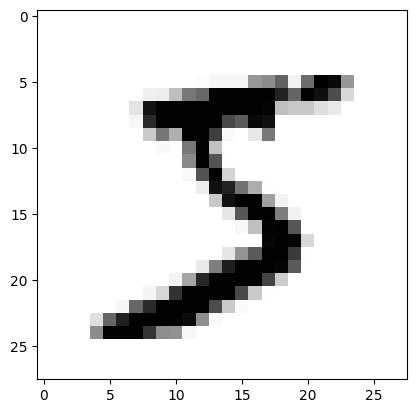

In [5]:
plt.imshow(X_train_0[0], cmap='Greys')
plt.show()

In [6]:
import sys

In [7]:
for x in X_train_0[0]:
    for i in x:
        sys.stdout.write('%4d'%i)
    sys.stdout.write('\n')

   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136 175  26 166 255 247 127   0   0   0   0
   0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253 225 172 253 242 195  64   0   0   0   0
   0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251  93  82  82  56  39   0   0   0   0   0
   0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 182 247 241   0   0   0   0   0   0

In [8]:
from tensorflow.python.keras.utils import np_utils

In [9]:
X_train = X_train_0.reshape(X_train_0.shape[0], 28, 28, 1).astype('float32') /255
X_test = X_test_0.reshape(X_test_0.shape[0], 28, 28, 1).astype('float32') /255

In [10]:
Y_train = np_utils.to_categorical(Y_train_0, 10)
Y_test = np_utils.to_categorical(Y_test_0, 10)
print(Y_train[0])

[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


In [11]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D
from keras.callbacks import ModelCheckpoint, EarlyStopping
import os

In [16]:
model = Sequential()
model.add(Conv2D(32, kernel_size = (3,3), input_shape = (28, 28, 1), activation='relu'))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPool2D(pool_size = 2))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(128, activation ='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation = 'softmax'))


/Users/eddy/workspace/data/data_crowling/.venv/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
model.compile(loss = 'categorical_crossentropy', optimizer = 'adam', metrics = ['accuracy'])

In [19]:
MODEL_DIR = './model'

if not os.path.exists(MODEL_DIR):
    os.mkdir(MODEL_DIR)

modelpath='model/{epoch:02d} - {val_loss:.4f}.keras'
checkpointer = ModelCheckpoint(filepath = modelpath, monitor = 'val_loss', verbose = 1, save_best_only=True)

early_stopping_callback = EarlyStopping(monitor = 'val_loss', patience = 5)

In [22]:
history  = model.fit(X_train, Y_train, validation_data=(X_test, Y_test), epochs = 30, batch_size = 200, verbose = 0, callbacks = [early_stopping_callback, checkpointer])


Epoch 1: val_loss improved from None to 0.05543, saving model to model/01 - 0.0554.keras

Epoch 2: val_loss improved from 0.05543 to 0.03489, saving model to model/02 - 0.0349.keras

Epoch 3: val_loss improved from 0.03489 to 0.03307, saving model to model/03 - 0.0331.keras

Epoch 4: val_loss improved from 0.03307 to 0.02877, saving model to model/04 - 0.0288.keras

Epoch 5: val_loss improved from 0.02877 to 0.02782, saving model to model/05 - 0.0278.keras

Epoch 6: val_loss improved from 0.02782 to 0.02755, saving model to model/06 - 0.0276.keras

Epoch 7: val_loss improved from 0.02755 to 0.02736, saving model to model/07 - 0.0274.keras

Epoch 8: val_loss did not improve from 0.02736

Epoch 9: val_loss did not improve from 0.02736

Epoch 10: val_loss did not improve from 0.02736

Epoch 11: val_loss did not improve from 0.02736

Epoch 12: val_loss improved from 0.02736 to 0.02658, saving model to model/12 - 0.0266.keras

Epoch 13: val_loss did not improve from 0.02658

Epoch 14: val_

In [23]:
print('\n Test Accuracy : %.4f' %(model.evaluate(X_test, Y_test)[1]))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9925 - loss: 0.0310

 Test Accuracy : 0.9925


In [24]:
import numpy as np

In [25]:
y_vloss = history.history['val_loss']
y_loss = history.history['loss']

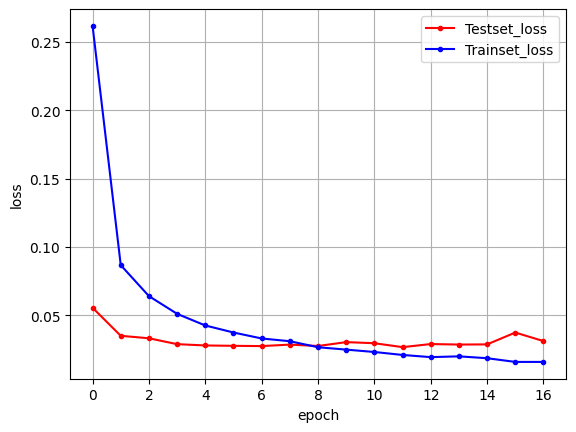

In [26]:
x_len = np.arange(len(y_loss))

plt.plot(x_len, y_vloss, marker ='.', c="red", label = "Testset_loss")
plt.plot(x_len, y_loss, marker = '.', c="blue", label = 'Trainset_loss')
plt.legend(loc = 'upper right')
plt.grid()
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

In [27]:
test_num = X_train[0].reshape(-1, 28, 28, 1)


In [28]:
prediction = model.predict(test_num)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


In [29]:
prediction

array([[3.2182771e-18, 4.9423472e-16, 3.5923929e-21, 2.3492990e-04,
        3.9925800e-18, 9.9976510e-01, 2.3610416e-13, 9.3535737e-13,
        3.7624692e-10, 9.0223336e-11]], dtype=float32)

In [34]:
print('입력한 이미지는 %f 확률로 %d 입니다 !' %(prediction[0, prediction.argmax()], prediction.argmax()))

입력한 이미지는 0.999765 확률로 5 입니다 !


In [30]:
from PIL import Image

In [38]:
test = Image.open('./14장_data/test7.jpg')
test.mode

'RGB'

In [39]:
test_gray = test.convert("L")
test_gray.mode

'L'

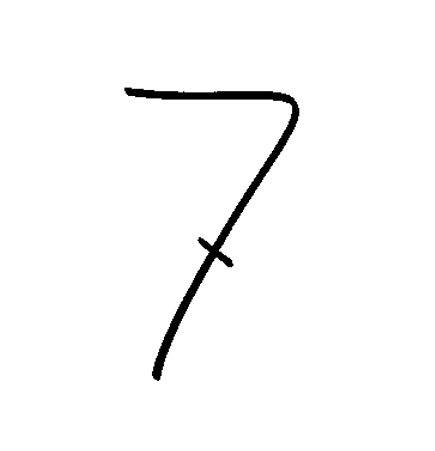

In [40]:
test_gray

In [41]:
test_gray = test_gray.resize((28,28))

In [42]:
test_data = np.asarray(test_gray)

for x in test_data:
    for i in x:
        sys.stdout.write("%4d" %i)
    sys.stdout.write('\n')

 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255
 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255
 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255
 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255
 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255
 255 255 255 255 255 255 255 249 160 158 170 176 186 183 169 168 168 174 212 255 255 255 255 255 255 255 255 255
 255 255 255 255 255 255 255 255 231 212 200 195 198 197 194 194 194 189 141 208 255 255 255 255 255 255 255 255
 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 166 201 255 255 255 255 255 255 255 255
 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 231 129 251 255 255 255 255

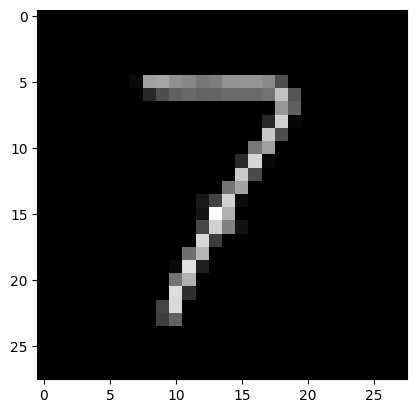

In [43]:
plt.imshow(test_data, cmap="Greys")
plt.show()

In [44]:
test_data_v = []

for i in range(28):
    row = []
    for j in range(28):
        row.append(255-test_data[i][j])
    test_data_v.append(row)

In [45]:
for x in test_data_v:
    for i in x:
        sys.stdout.write('%4d' %i)
    sys.stdout.write('\n')

   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   6  95  97  85  79  69  72  86  87  87  81  43   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0  24  43  55  60  57  58  61  61  61  66 114  47   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  89  54   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  24 126   4   0   0   0   0

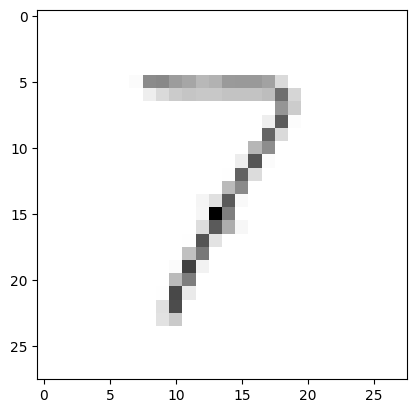

In [46]:
plt.imshow(test_data_v, cmap="Greys")
plt.show()

In [47]:
test_data_v2 = np.asarray(test_data_v)
test_data_v2 = test_data_v2.reshape(-1, 28, 28, 1).astype('float32') /255
test_data_v2.shape

(1, 28, 28, 1)

In [48]:
prediction_new = model.predict(test_data_v2)
prediction_new

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


array([[1.6671660e-05, 1.4493020e-02, 1.1130764e-01, 1.6616991e-02,
        7.8479687e-05, 2.8871667e-05, 2.9064277e-05, 8.5571271e-01,
        2.7470163e-04, 1.4419041e-03]], dtype=float32)

In [49]:
test_class = prediction_new.argmax()

print('입력한 이미지는 %f 확률로 %d 입니다 !' %(prediction_new[0, test_class] * 100, test_class))

입력한 이미지는 85.571274 확률로 7 입니다 !
